In [1]:
import io
import os
import pandas as pd
import gzip as gz
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib_venn import venn2, venn3

sns.set_theme(font="Arial", font_scale=1.15, style='ticks')
plt.rc("axes.spines", top=False, right=False)

def read_vcf(path):
    with gz.open(path, 'rb') as f:
        lines = [l.decode('utf-8') for l in f if not l.startswith(b'##')]
    return pd.read_csv(
        io.StringIO(''.join(lines)),
        dtype={'#CHROM': str, 'POS': int, 'ID': str, 'REF': str, 'ALT': str,
               'QUAL': str, 'FILTER': str, 'INFO': str},
        sep='\t'
    ).rename(columns={'#CHROM': 'CHROM'})

dir="/mmfs1/gscratch/stergachislab/mhsohny/SMaHT/Improving_SomaticVariantCalling_through_DSA/Fiber-seq/VariantCalls_DeepVariant_1.6.1"

In [2]:
'''
colobl_vcf = read_vcf(f"{dir}/COLO829BL/deepvariant/COLO829BL.deepvariant.vcf.gz")
colotb_vcf = read_vcf(f"{dir}/COLO829T_PassageB_DSA/deepvariant/COLO829T_PassageB_DSA.deepvariant.vcf.gz")
colota_vcf = read_vcf(f"{dir}/COLO829T_PassageA_DSA/deepvariant/COLO829T_PassageA_DSA.deepvariant.vcf.gz")
'''
colobl_vcf = read_vcf(f"{dir}/COLO829BL/deepvariant/COLO829BL.deepvariant.split.snv.modified.vcf.gz")
colotb_vcf = read_vcf(f"{dir}/COLO829T_PassageB_DSA/deepvariant/COLO829T_PassageB_DSA.deepvariant.split.snv.modified.vcf.gz")
colota_vcf = read_vcf(f"{dir}/COLO829T_PassageA_DSA/deepvariant/COLO829T_PassageA_DSA.deepvariant.split.snv.modified.vcf.gz")


## Simple Stats

In [3]:
colobl_vcf

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,COLO829BL
0,haplotype1-0000001,69010,.,G,A,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:33:39:22,8:0.205128:0,32,46"
1,haplotype1-0000001,119793,.,T,G,48.2,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:46:190:87,96:0.505263:48,0,51"
2,haplotype1-0000001,1590039,.,T,A,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:22:172:122,34:0.197674:0,22,47"
3,haplotype1-0000001,1590040,.,A,T,0,RefCall,.,GT:GQ:DP:AD:VAF:PL,"0/0:43:154:127,22:0.142857:0,43,59"
4,haplotype1-0000001,2005079,.,A,T,0.1,RefCall,.,GT:GQ:DP:AD:VAF:PL,"./.:19:174:113,38:0.218391:0,18,46"
...,...,...,...,...,...,...,...,...,...,...
902920,haplotype2-0000195,23040,.,C,T,11.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:11:56:48,8:0.142857:11,0,44"
902921,haplotype2-0000195,23111,.,A,T,1.9,RefCall,.,GT:GQ:DP:AD:VAF:PL,"./.:5:55:47,8:0.145455:0,2,40"
902922,haplotype2-0000195,23141,.,A,G,14.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:15:55:47,8:0.145455:14,0,44"
902923,haplotype2-0000195,23237,.,A,G,11.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:11:55:47,8:0.145455:11,0,42"


In [4]:
'''
print(f"COLO829BL PASS variants from all tested alleles: {round(colobl_vcf[colobl_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colobl_vcf.index.shape[0], 2)} %")
print(f"COLO829BL PASS SNVs from all tested SNV alleles: {round(colobl_vcf[(colobl_vcf['FILTER'] == 'PASS') & (colobl_vcf['REF'].str.len() == 1) & (colobl_vcf['ALT'].str.len() == 1)].index.shape[0]*100 / colobl_vcf[((colobl_vcf['REF']).str.len() ==1) & (colobl_vcf['ALT'].str.len()==1)].index.shape[0], 2)} %")

print(f"COLO829T (Passage B) PASS variants from all tested alleles: {round(colotb_vcf[colotb_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colotb_vcf.index.shape[0], 2)} %")
print(f"COLO829T (Passage B) PASS SNVs from all tested SNV alleles: {round(colotb_vcf[(colotb_vcf['FILTER'] == 'PASS') & (colotb_vcf['REF'].str.len() == 1) & (colotb_vcf['ALT'].str.len() == 1)].index.shape[0]*100 / colotb_vcf[((colotb_vcf['REF']).str.len() ==1) & (colotb_vcf['ALT'].str.len()==1)].index.shape[0], 2)} %")

print(f"COLO829T (Passage A) PASS variants from all tested alleles: {round(colota_vcf[colota_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colota_vcf.index.shape[0], 2)} %")
print(f"COLO829T (Passage A) PASS SNVs from all tested SNV alleles: {round(colota_vcf[(colota_vcf['FILTER'] == 'PASS') & (colota_vcf['REF'].str.len() == 1) & (colota_vcf['ALT'].str.len() == 1)].index.shape[0]*100 / colota_vcf[((colota_vcf['REF']).str.len() ==1) & (colota_vcf['ALT'].str.len()==1)].index.shape[0], 2)} %")
'''
print(f"COLO829BL PASS SNVs from all tested SNV alleles: {round(colobl_vcf[colobl_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colobl_vcf.index.shape[0], 2)} %")
print(f"COLO829T (Passage B) PASS SNVs from all tested SNV alleles: {round(colotb_vcf[colotb_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colotb_vcf.index.shape[0], 2)} %")
print(f"COLO829T (Passage A) PASS SNVs from all tested SNV alleles: {round(colota_vcf[colota_vcf['FILTER'] == 'PASS'].index.shape[0]*100 / colota_vcf.index.shape[0], 2)} %")

COLO829BL PASS SNVs from all tested SNV alleles: 13.74 %
COLO829T (Passage B) PASS SNVs from all tested SNV alleles: 20.88 %
COLO829T (Passage A) PASS SNVs from all tested SNV alleles: 22.42 %


In [5]:
colobl_snvs_pass = colobl_vcf[(colobl_vcf['FILTER'] == 'PASS')].reset_index(drop=True)
colotb_snvs_pass = colotb_vcf[(colotb_vcf['FILTER'] == 'PASS')].reset_index(drop=True)
colota_snvs_pass = colota_vcf[(colota_vcf['FILTER'] == 'PASS')].reset_index(drop=True)

colobl_snvs_refcall = colobl_vcf[(colobl_vcf['FILTER'] == 'RefCall')].reset_index(drop=True)
colotb_snvs_refcall = colotb_vcf[(colotb_vcf['FILTER'] == 'RefCall')].reset_index(drop=True)
colota_snvs_refcall = colota_vcf[(colota_vcf['FILTER'] == 'RefCall')].reset_index(drop=True)

In [6]:
vafindex = list(set(colobl_snvs_pass['FORMAT'].values))[0].split(':').index('VAF')
dpindex = list(set(colobl_snvs_pass['FORMAT'].values))[0].split(':').index('DP')
adindex = list(set(colobl_snvs_pass['FORMAT'].values))[0].split(':').index('AD')

print(vafindex, dpindex, adindex)

4 2 3


Minimum VAF for PASS SNVs in COLO829BL: 0.12
Minimum VAF for PASS SNVs  in COLO829T (Passage B): 0.12
Minimum VAF for PASS SNVs  in COLO829T (Passage A): 0.12
Minimum VAF for RefCall SNVs in COLO829BL: 0.12
Minimum VAF for RefCall SNVs  in COLO829T (Passage B): 0.12
Minimum VAF for RefCall SNVs  in COLO829T (Passage A): 0.12


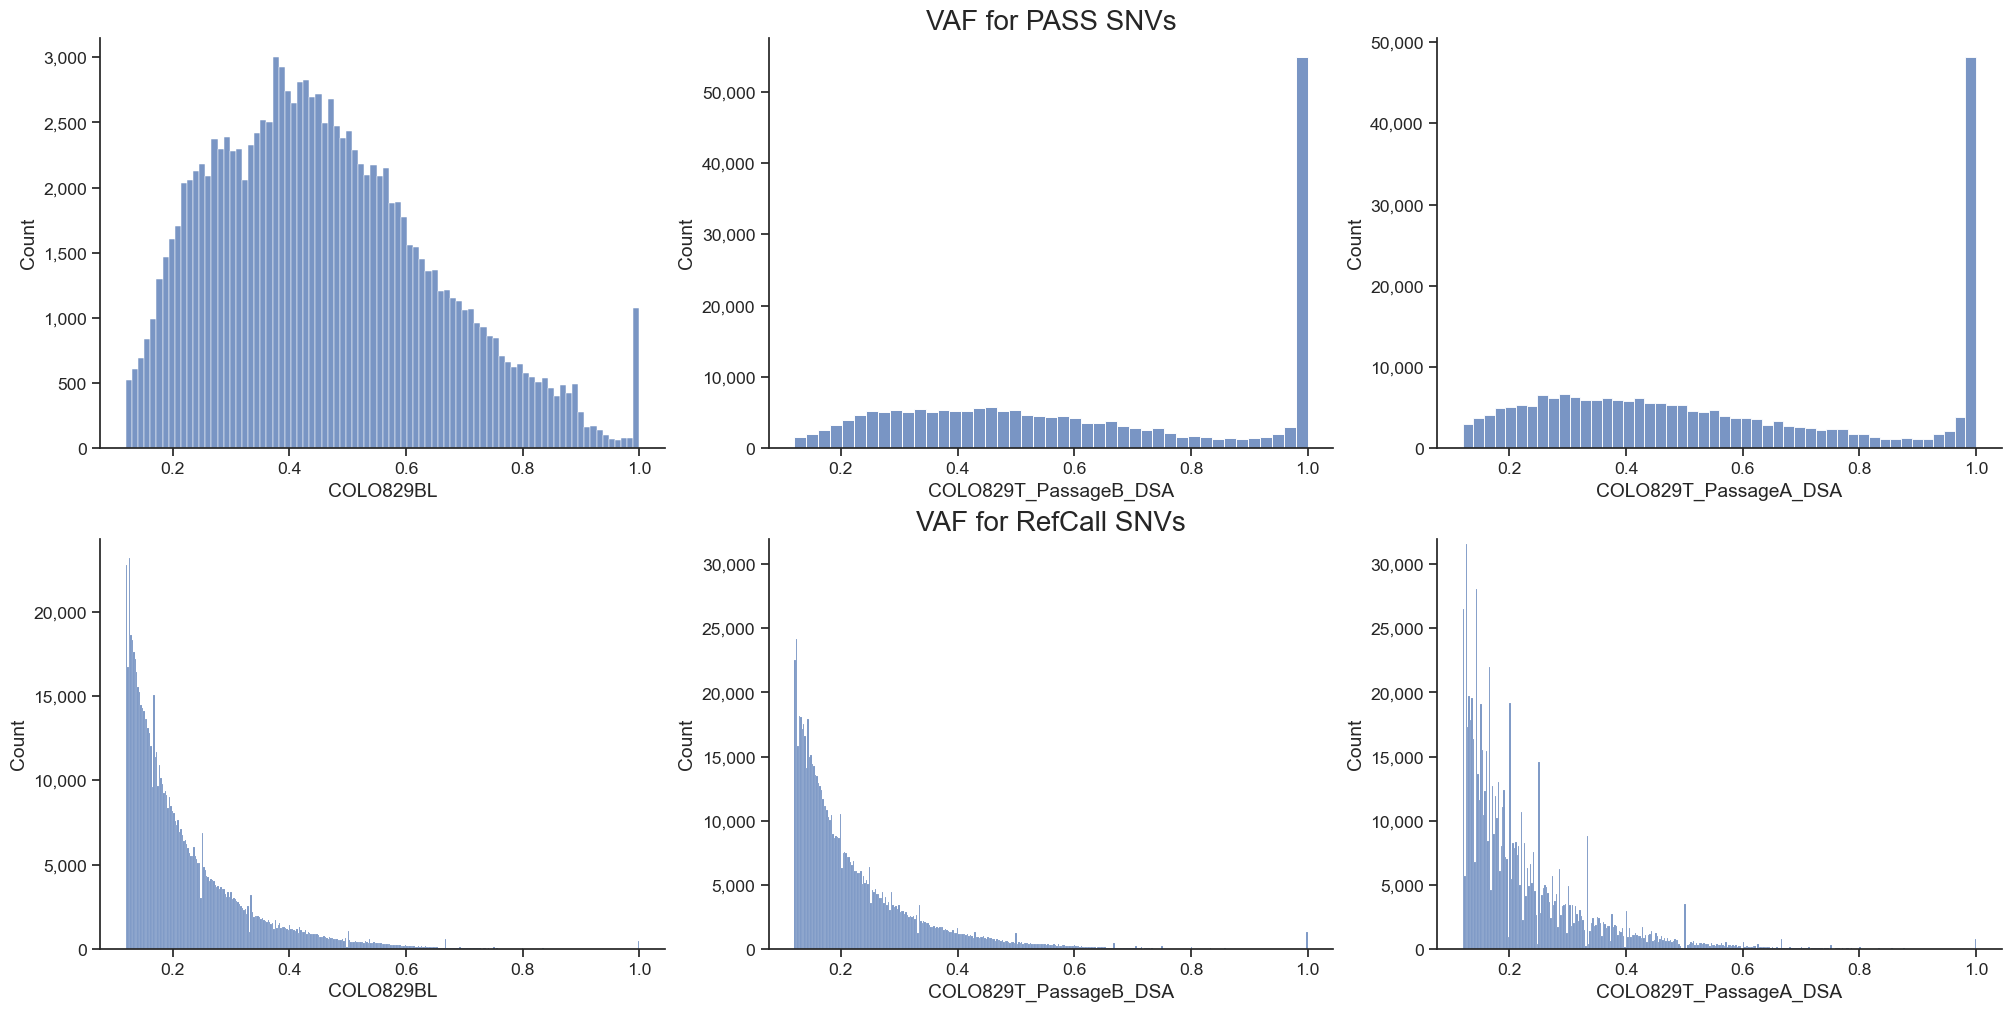

In [7]:
'''
stat
-count: show the number of observations in each bin
-frequency: show the number of observations divided by the bin width
-probability or proportion: normalize such that bar heights sum to 1
-percent: normalize such that bar heights sum to 100
-density: normalize such that the total area of the histogram equals 1
'''
fig, axes = plt.subplots(2,3, figsize=(20,10), constrained_layout=True)
sns.histplot(colobl_snvs_pass['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0,0])
axes[0,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_pass['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0,1])
axes[0,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs_pass['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0,2])
axes[0,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.histplot(colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1,0])
axes[1,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1,1])
axes[1,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[1,1].set_ylim(0, 32000)
sns.histplot(colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1,2])
axes[1,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[1,2].set_ylim(0, 32000)

axes[0, 1].set_title('VAF for PASS SNVs', loc='center', fontsize=20)
axes[1, 1].set_title('VAF for RefCall SNVs', loc='center', fontsize=20)

print(f"Minimum VAF for PASS SNVs in COLO829BL: {colobl_snvs_pass['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for PASS SNVs  in COLO829T (Passage B): {colotb_snvs_pass['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for PASS SNVs  in COLO829T (Passage A): {colota_snvs_pass['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")

print(f"Minimum VAF for RefCall SNVs in COLO829BL: {colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for RefCall SNVs  in COLO829T (Passage B): {colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for RefCall SNVs  in COLO829T (Passage A): {colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")

Minimum DP for PASS SNVs in COLO829BL: 2
Minimum DP for PASS SNVs  in COLO829T (Passage B): 2
Minimum DP for PASS SNVs  in COLO829T (Passage A): 2
Minimum DP for RefCall SNVs in COLO829BL: 2
Minimum DP for RefCall SNVs  in COLO829T (Passage B): 2
Minimum DP for RefCall SNVs  in COLO829T (Passage A): 2


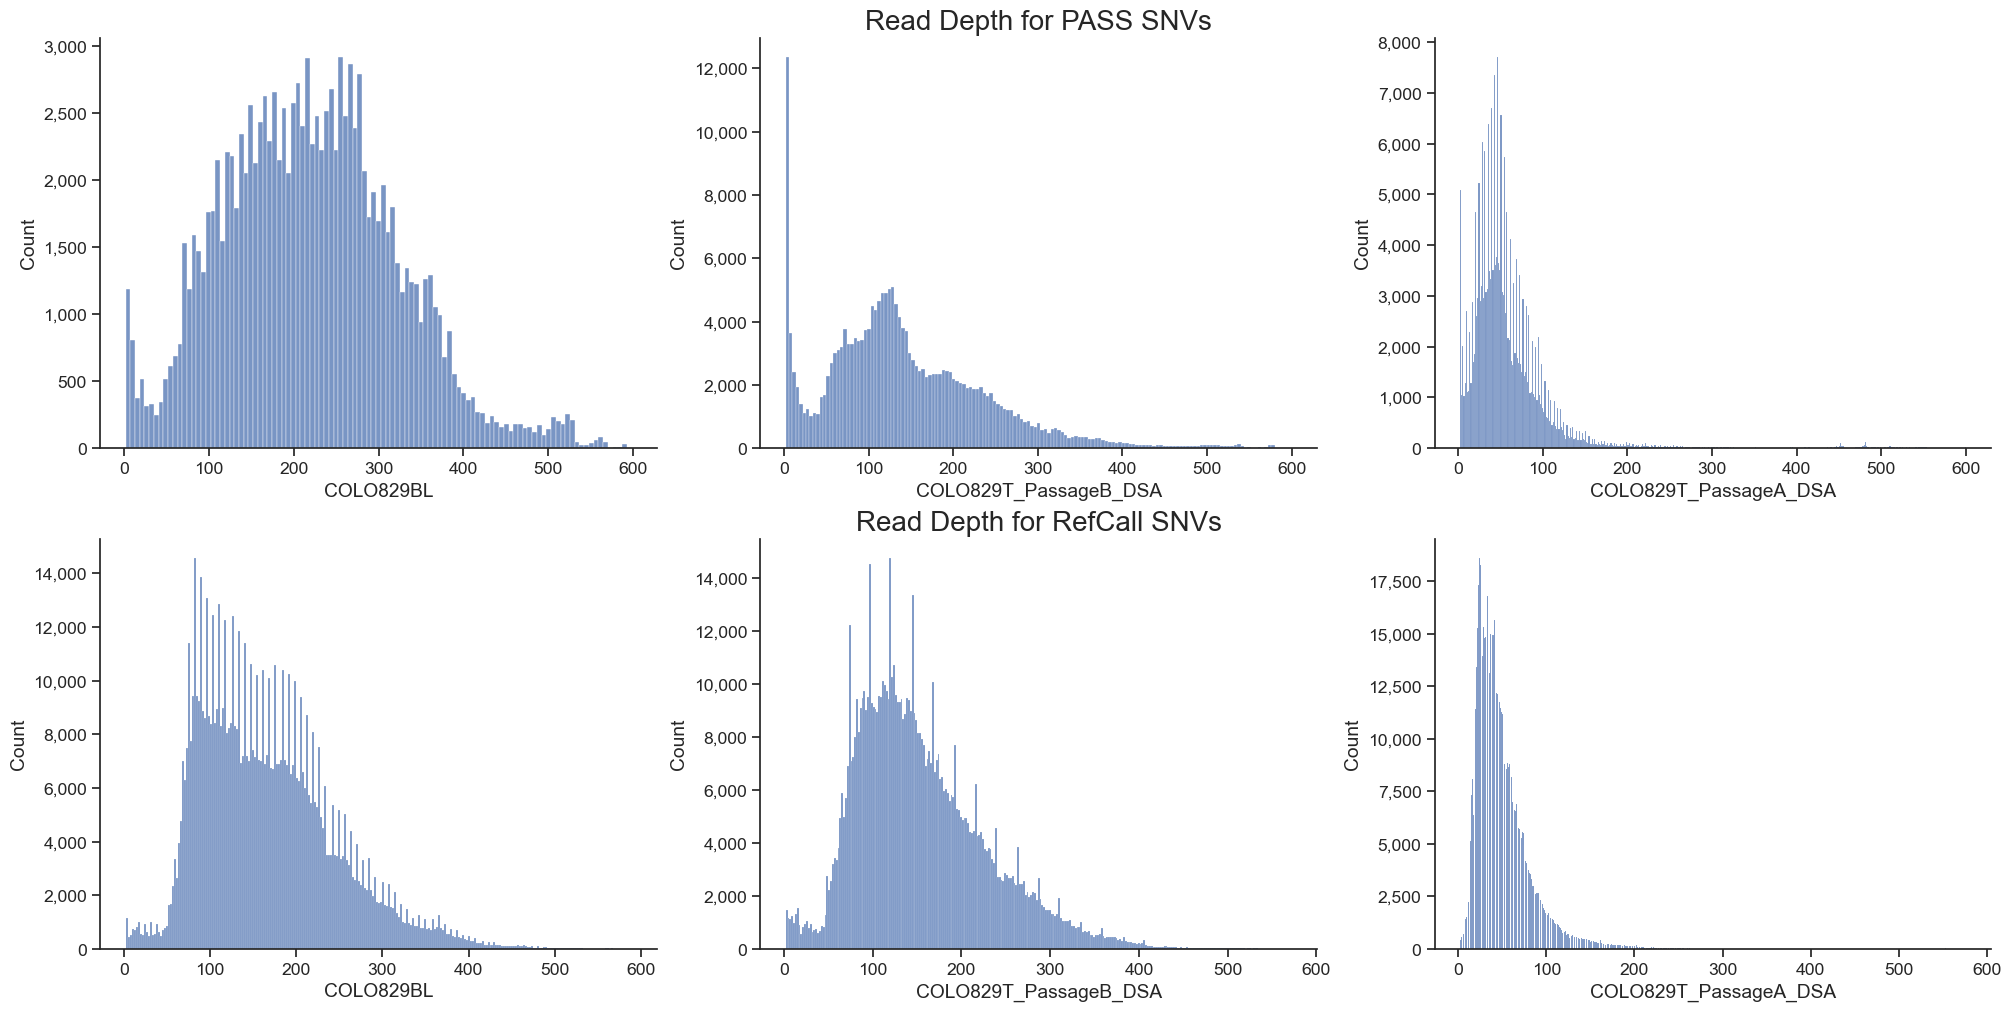

In [8]:
fig, axes = plt.subplots(2,3, figsize=(20,10), constrained_layout=True)
sns.histplot(colobl_snvs_pass['COLO829BL'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[0,0])
axes[0,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_pass['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[0,1])
axes[0,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs_pass['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[0,2])
axes[0,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.histplot(colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[1,0])
axes[1,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[1,1])
axes[1,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[dpindex])), ax=axes[1,2])
axes[1,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

axes[0, 1].set_title('Read Depth for PASS SNVs', loc='center', fontsize=20)
axes[1, 1].set_title('Read Depth for RefCall SNVs', loc='center', fontsize=20)

print(f"Minimum DP for PASS SNVs in COLO829BL: {colobl_snvs_pass['COLO829BL'].str.split(':').apply(lambda x: int(x[dpindex])).min()}")
print(f"Minimum DP for PASS SNVs  in COLO829T (Passage B): {colotb_snvs_pass['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[dpindex])).min()}")
print(f"Minimum DP for PASS SNVs  in COLO829T (Passage A): {colota_snvs_pass['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[dpindex])).min()}")

print(f"Minimum DP for RefCall SNVs in COLO829BL: {colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: int(x[dpindex])).min()}")
print(f"Minimum DP for RefCall SNVs  in COLO829T (Passage B): {colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[dpindex])).min()}")
print(f"Minimum DP for RefCall SNVs  in COLO829T (Passage A): {colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[dpindex])).min()}")

Minimum AD for PASS SNVs in COLO829BL: 2
Minimum AD for PASS SNVs  in COLO829T (Passage B): 2
Minimum AD for PASS SNVs  in COLO829T (Passage A): 2
Minimum AD for RefCall SNVs in COLO829BL: 2
Minimum AD for RefCall SNVs  in COLO829T (Passage B): 2
Minimum AD for RefCall SNVs  in COLO829T (Passage A): 2


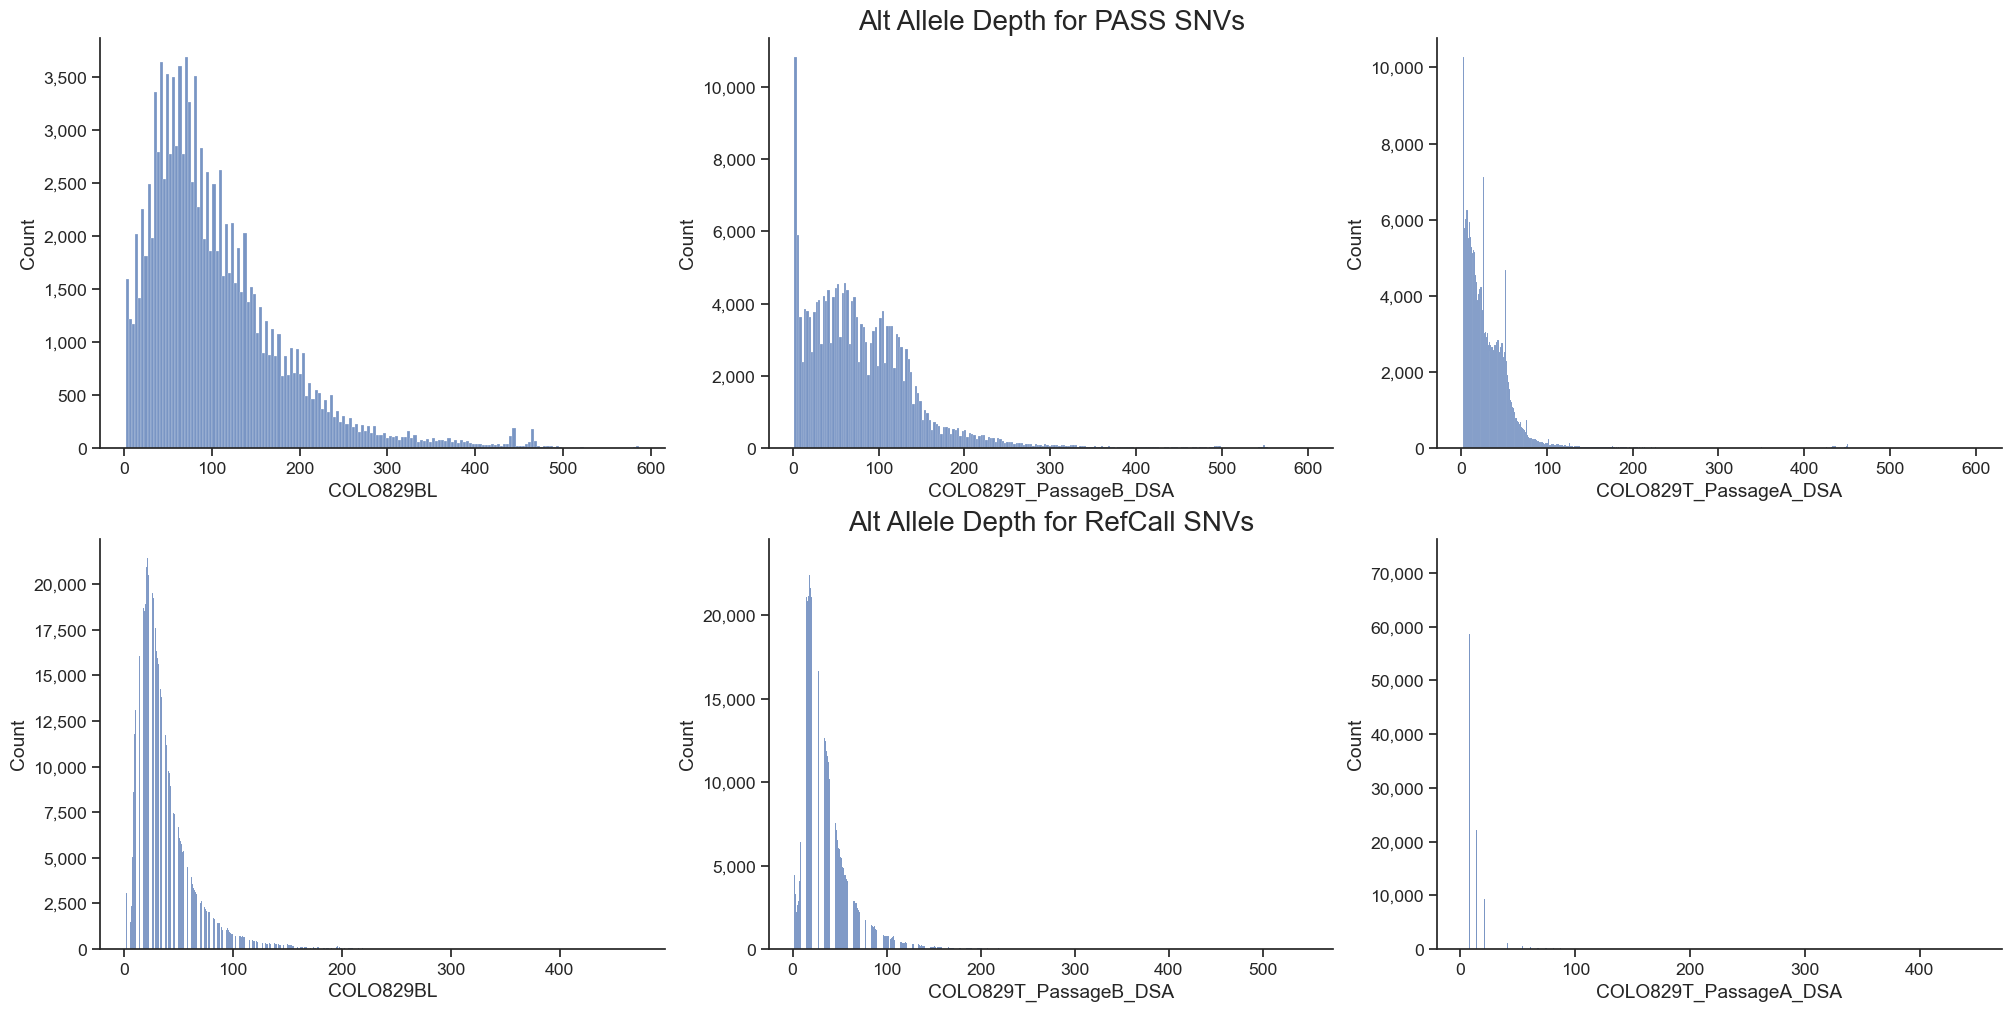

In [9]:
fig, axes = plt.subplots(2,3, figsize=(20,10), constrained_layout=True)
sns.histplot(colobl_snvs_pass['COLO829BL'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])), ax=axes[0,0])
axes[0,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_pass['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])), ax=axes[0,1])
axes[0,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs_pass['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])), ax=axes[0,2])
axes[0,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.histplot(colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])), ax=axes[1,0])
axes[1,0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])), ax=axes[1,1])
axes[1,1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])), ax=axes[1,2])
axes[1,2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

axes[0, 1].set_title('Alt Allele Depth for PASS SNVs', loc='center', fontsize=20)
axes[1, 1].set_title('Alt Allele Depth for RefCall SNVs', loc='center', fontsize=20)

print(f"Minimum AD for PASS SNVs in COLO829BL: {colobl_snvs_pass['COLO829BL'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])).min()}")
print(f"Minimum AD for PASS SNVs  in COLO829T (Passage B): {colotb_snvs_pass['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])).min()}")
print(f"Minimum AD for PASS SNVs  in COLO829T (Passage A): {colota_snvs_pass['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])).min()}")

print(f"Minimum AD for RefCall SNVs in COLO829BL: {colobl_snvs_refcall['COLO829BL'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])).min()}")
print(f"Minimum AD for RefCall SNVs  in COLO829T (Passage B): {colotb_snvs_refcall['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])).min()}")
print(f"Minimum AD for RefCall SNVs  in COLO829T (Passage A): {colota_snvs_refcall['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])).min()}")

In [10]:
colobl_snvs_pass['COLO829BL'].str.split(':').apply(lambda x: int(x[dpindex])).sort_values()
colobl_snvs_pass.iloc[36712]
#print(colobl_snvs_pass.iloc[36712]['CHROM'] + ':' + str(colobl_snvs_pass.iloc[36712]['POS']))
#print(colobl_snvs_pass.iloc[45723]['CHROM'] + ':' + str(colobl_snvs_pass.iloc[45723]['POS']))

CHROM          haplotype1-0000027
POS                     153943469
ID                              .
REF                             A
ALT                             C
QUAL                           33
FILTER                       PASS
INFO                            .
FORMAT         GT:GQ:DP:AD:VAF:PL
COLO829BL    1/1:7:2:0,2:1:31,5,0
Name: 36712, dtype: object

In [11]:
'''
colobl_vcf[
    (colobl_vcf['FILTER'] == 'PASS') &
    (colobl_vcf['REF'].str.len() == 1) &
    (colobl_vcf['ALT'].apply(lambda x: any(len(alt) == 1 for alt in x.split(','))))
    ]

colobl_vcf[
    (colobl_vcf['FILTER'] == 'PASS') &
    (colobl_vcf['REF'].str.len() == 1) &
    (colobl_vcf['ALT'].apply(lambda x: all(len(alt) == 1 for alt in x.split(','))))
    ]

colobl_vcf[
    (colobl_vcf['FILTER'] == 'PASS') &
    (colobl_vcf['REF'].str.len() == 2) &
    (colobl_vcf['ALT'].apply(lambda x: any(len(alt) == 2 for alt in x.split(','))))
    ]
'''

"\ncolobl_vcf[\n    (colobl_vcf['FILTER'] == 'PASS') &\n    (colobl_vcf['REF'].str.len() == 1) &\n    (colobl_vcf['ALT'].apply(lambda x: any(len(alt) == 1 for alt in x.split(','))))\n    ]\n\ncolobl_vcf[\n    (colobl_vcf['FILTER'] == 'PASS') &\n    (colobl_vcf['REF'].str.len() == 1) &\n    (colobl_vcf['ALT'].apply(lambda x: all(len(alt) == 1 for alt in x.split(','))))\n    ]\n\ncolobl_vcf[\n    (colobl_vcf['FILTER'] == 'PASS') &\n    (colobl_vcf['REF'].str.len() == 2) &\n    (colobl_vcf['ALT'].apply(lambda x: any(len(alt) == 2 for alt in x.split(','))))\n    ]\n"

## Final Filtering (w/ AD)

In [12]:
colobl_snvs_pass, colotb_snvs_pass, colota_snvs_pass

(                     CHROM      POS ID REF ALT  QUAL FILTER INFO  \
 0       haplotype1-0000001   119793  .   T   G  48.2   PASS    .   
 1       haplotype1-0000001  2005081  .   T   A   8.8   PASS    .   
 2       haplotype1-0000001  3266005  .   G   T  29.8   PASS    .   
 3       haplotype1-0000001  4855815  .   A   C  30.2   PASS    .   
 4       haplotype1-0000001  6364498  .   A   G  45.1   PASS    .   
 ...                    ...      ... ..  ..  ..   ...    ...  ...   
 124026  haplotype2-0000195    23029  .   C   T   7.4   PASS    .   
 124027  haplotype2-0000195    23040  .   C   T  11.4   PASS    .   
 124028  haplotype2-0000195    23141  .   A   G  14.8   PASS    .   
 124029  haplotype2-0000195    23237  .   A   G  11.4   PASS    .   
 124030  haplotype2-0000195    23256  .   G   A  18.1   PASS    .   
 
                     FORMAT                           COLO829BL  
 0       GT:GQ:DP:AD:VAF:PL   0/1:46:190:87,96:0.505263:48,0,51  
 1       GT:GQ:DP:AD:VAF:PL     0/1:9:

In [13]:
'''
print('COLO829BL SNV Before AD filtering: ', f'{colobl_snvs_pass.shape[0]:,}')
print('COLO829BL SNV After  AD filtering : ', f'{colobl_snvs_pass[( colobl_snvs_pass['COLO829BL'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])) >= 10 )].shape[0]:,}')
print('COLO829T Passage B SNV Before AD filtering: ', f'{colotb_snvs_pass.shape[0]:,}')
print('COLO829T Passage B SNV After  AD filtering: ', f'{colotb_snvs_pass[( colotb_snvs_pass['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])) >= 10 )].shape[0]:,}')
print('COLO829T Passage A SNV Before AD filtering: ', f'{colota_snvs_pass.shape[0]:,}')
print('COLO829T Passage B SNV After  AD filtering: ', f'{colota_snvs_pass[( colota_snvs_pass['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])) >= 10 )].shape[0]:,}')
'''
colobl_snvs_pass_ad10 = colobl_snvs_pass[( colobl_snvs_pass['COLO829BL'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])) >= 10 )].reset_index(drop=True)
colotb_snvs_pass_ad10 = colotb_snvs_pass[( colotb_snvs_pass['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])) >= 10 )].reset_index(drop=True)
colota_snvs_pass_ad10 = colota_snvs_pass[( colota_snvs_pass['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])) >= 10 )].reset_index(drop=True)

print('COLO829BL SNV Before AD≥10 filtering: ', f'{colobl_snvs_pass.shape[0]:,}')
print('COLO829BL SNV After  AD≥10 filtering : ', f'{colobl_snvs_pass_ad10.shape[0]:,}')
print('COLO829T Passage B SNV Before AD≥10 filtering: ', f'{colotb_snvs_pass.shape[0]:,}')
print('COLO829T Passage B SNV After  AD≥10 filtering: ', f'{colotb_snvs_pass_ad10.shape[0]:,}')
print('COLO829T Passage A SNV Before AD≥10 filtering: ', f'{colota_snvs_pass.shape[0]:,}')
print('COLO829T Passage A SNV After  AD≥10 filtering: ', f'{colota_snvs_pass_ad10.shape[0]:,}')

COLO829BL SNV Before AD≥10 filtering:  124,031
COLO829BL SNV After  AD≥10 filtering :  121,222
COLO829T Passage B SNV Before AD≥10 filtering:  205,113
COLO829T Passage B SNV After  AD≥10 filtering:  185,811
COLO829T Passage A SNV Before AD≥10 filtering:  230,756
COLO829T Passage A SNV After  AD≥10 filtering:  185,720


In [14]:
colobl_snvs_pass_ad30 = colobl_snvs_pass[( colobl_snvs_pass['COLO829BL'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])) >= 30 )].reset_index(drop=True)
colotb_snvs_pass_ad30 = colotb_snvs_pass[( colotb_snvs_pass['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])) >= 30 )].reset_index(drop=True)
colota_snvs_pass_ad30 = colota_snvs_pass[( colota_snvs_pass['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: int(x[adindex].split(',')[1])) >= 30 )].reset_index(drop=True)

print('COLO829BL SNV Before AD≥30 filtering: ', f'{colobl_snvs_pass.shape[0]:,}')
print('COLO829BL SNV After  AD≥30 filtering : ', f'{colobl_snvs_pass_ad30.shape[0]:,}')
print('COLO829T Passage B SNV Before AD≥30 filtering: ', f'{colotb_snvs_pass.shape[0]:,}')
print('COLO829T Passage B SNV After  AD≥30 filtering: ', f'{colotb_snvs_pass_ad30.shape[0]:,}')
print('COLO829T Passage A SNV Before AD≥30 filtering: ', f'{colota_snvs_pass.shape[0]:,}')
print('COLO829T Passage A SNV After  AD≥30 filtering: ', f'{colota_snvs_pass_ad30.shape[0]:,}')

COLO829BL SNV Before AD≥30 filtering:  124,031
COLO829BL SNV After  AD≥30 filtering :  110,694
COLO829T Passage B SNV Before AD≥30 filtering:  205,113
COLO829T Passage B SNV After  AD≥30 filtering:  160,586
COLO829T Passage A SNV Before AD≥30 filtering:  230,756
COLO829T Passage A SNV After  AD≥30 filtering:  98,246


Minimum VAF for PASS SNVs in COLO829BL: 0.12
Minimum VAF for PASS SNVs  in COLO829T (Passage B): 0.12
Minimum VAF for PASS SNVs  in COLO829T (Passage A): 0.12


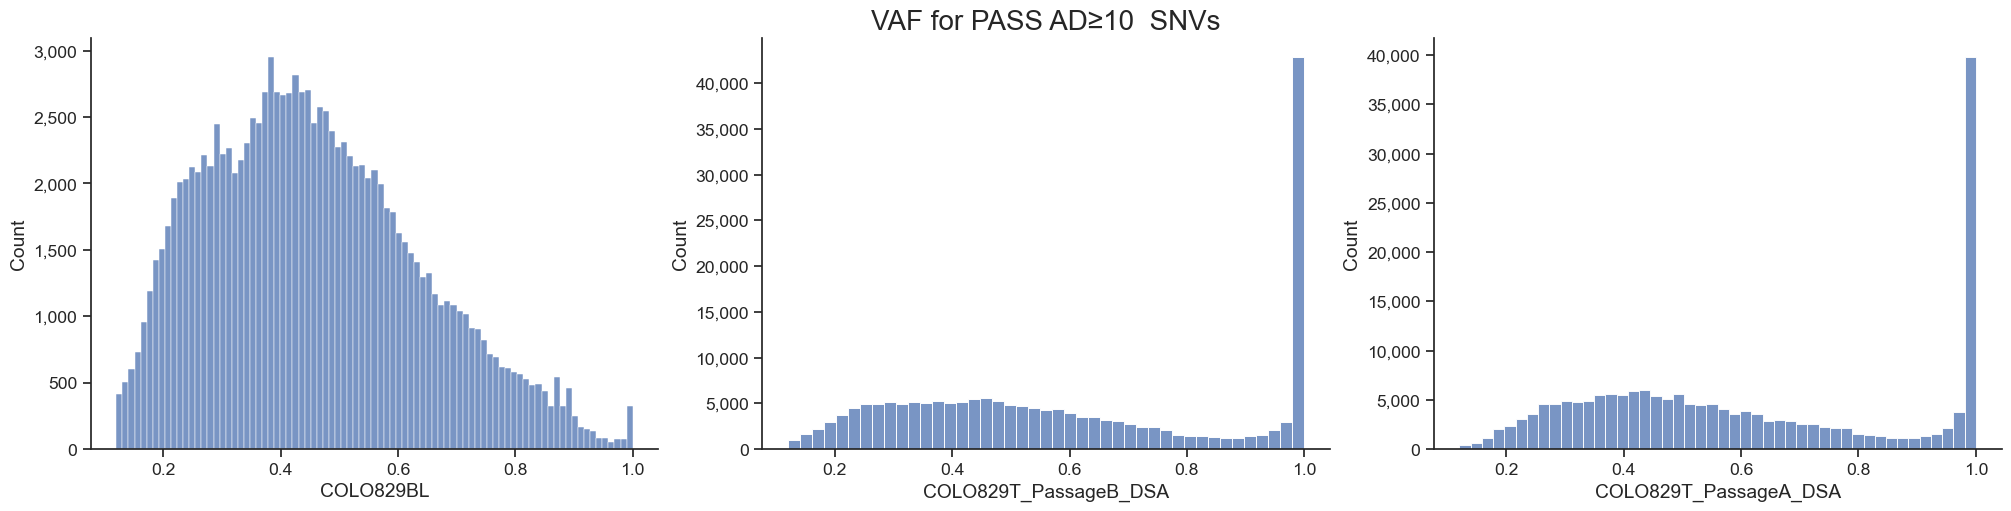

In [15]:
fig, axes = plt.subplots(1,3, figsize=(20,5), constrained_layout=True)
sns.histplot(colobl_snvs_pass_ad10['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0])
axes[0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_pass_ad10['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1])
axes[1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs_pass_ad10['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[2])
axes[2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

axes[1].set_title('VAF for PASS AD≥10  SNVs', loc='center', fontsize=20)

print(f"Minimum VAF for PASS SNVs in COLO829BL: {colobl_snvs_pass_ad10['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for PASS SNVs  in COLO829T (Passage B): {colotb_snvs_pass_ad10['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for PASS SNVs  in COLO829T (Passage A): {colota_snvs_pass_ad10['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")

Minimum VAF for PASS SNVs in COLO829BL: 0.12
Minimum VAF for PASS SNVs  in COLO829T (Passage B): 0.120112
Minimum VAF for PASS SNVs  in COLO829T (Passage A): 0.120301


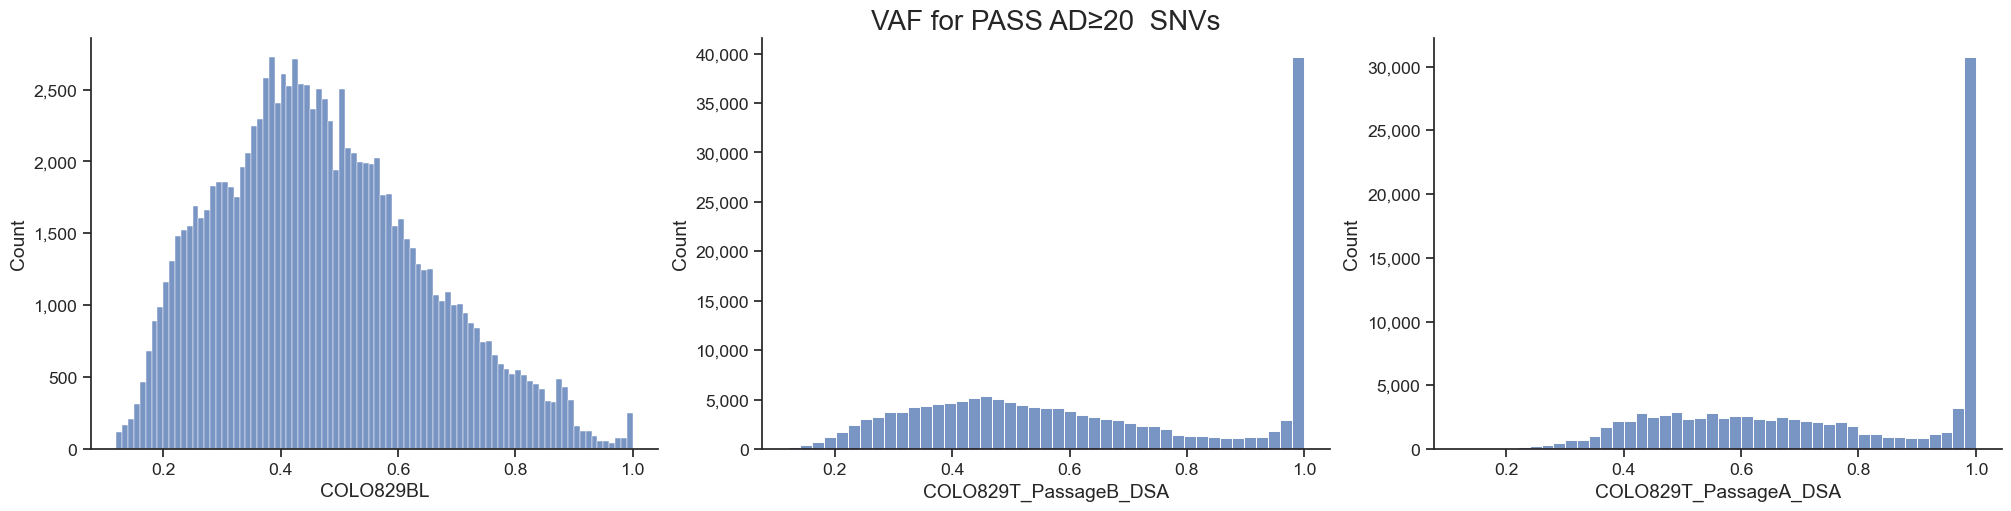

In [16]:
fig, axes = plt.subplots(1,3, figsize=(20,5), constrained_layout=True)
sns.histplot(colobl_snvs_pass_ad30['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0])
axes[0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colotb_snvs_pass_ad30['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1])
axes[1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
sns.histplot(colota_snvs_pass_ad30['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[2])
axes[2].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

axes[1].set_title('VAF for PASS AD≥20  SNVs', loc='center', fontsize=20)

print(f"Minimum VAF for PASS SNVs in COLO829BL: {colobl_snvs_pass_ad30['COLO829BL'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for PASS SNVs  in COLO829T (Passage B): {colotb_snvs_pass_ad30['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")
print(f"Minimum VAF for PASS SNVs  in COLO829T (Passage A): {colota_snvs_pass_ad30['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])).min()}")

## Comparison btw Passage B and Passage A

In [17]:
colobl_snvs_pass_ad10

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,COLO829BL
0,haplotype1-0000001,119793,.,T,G,48.2,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:46:190:87,96:0.505263:48,0,51"
1,haplotype1-0000001,2005081,.,T,A,8.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:9:123:68,55:0.447154:8,0,27"
2,haplotype1-0000001,3266005,.,G,T,29.8,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:30:175:107,68:0.388571:29,0,52"
3,haplotype1-0000001,4855815,.,A,C,30.2,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:2:142:49,72:0.507042:26,13,1"
4,haplotype1-0000001,6364498,.,A,G,45.1,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:45:200:105,94:0.47:45,0,57"
...,...,...,...,...,...,...,...,...,...,...
121217,haplotype2-0000190,18491,.,G,T,7.3,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:7:35:17,18:0.514286:6,0,34"
121218,haplotype2-0000190,18640,.,A,T,29.4,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:29:35:17,17:0.485714:29,0,47"
121219,haplotype2-0000190,18662,.,A,G,22.9,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:23:34:16,18:0.529412:22,0,43"
121220,haplotype2-0000190,18775,.,C,T,19.1,PASS,.,GT:GQ:DP:AD:VAF:PL,"0/1:19:33:16,17:0.515152:19,0,41"


In [18]:
colobl_snvs_pass_ad10['SNVid'] = colobl_snvs_pass_ad10[['CHROM', 'POS', 'REF', 'ALT']].astype(str).apply('_'.join, axis=1)
colotb_snvs_pass_ad10['SNVid'] = colotb_snvs_pass_ad10[['CHROM', 'POS', 'REF', 'ALT']].astype(str).apply('_'.join, axis=1)
colota_snvs_pass_ad10['SNVid'] = colota_snvs_pass_ad10[['CHROM', 'POS', 'REF', 'ALT']].astype(str).apply('_'.join, axis=1)

colobl_snvs_pass_ad10_set = set(colobl_snvs_pass_ad10['SNVid'].values)
colotb_snvs_pass_ad10_set = set(colotb_snvs_pass_ad10['SNVid'].values)
colota_snvs_pass_ad10_set = set(colota_snvs_pass_ad10['SNVid'].values)

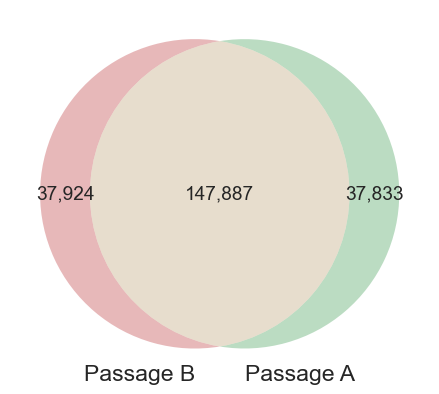

In [ ]:
venn1 = venn2([colotb_snvs_pass_ad10_set, colota_snvs_pass_ad10_set], ('Passage B', 'Passage A'))
for idx, subset in enumerate(venn1.subset_labels):
    if subset:
        venn1.subset_labels[idx].set_text(f"{int(subset.get_text()):,}")

'\n#check\nprint(18500 + 10554 + 12324 + 79844)\nprint(25600 + 12324 + 79844 + 68043)\nprint(79844 + 68043 + 10554 + 27279)\n'

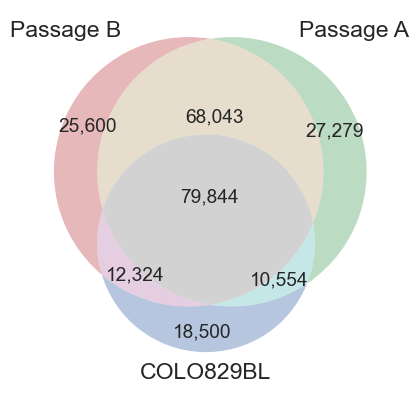

In [20]:
venn2 = venn3([colotb_snvs_pass_ad10_set, colota_snvs_pass_ad10_set, colobl_snvs_pass_ad10_set], ('Passage B', 'Passage A', 'COLO829BL'))

for idx, subset in enumerate(venn2.subset_labels):
    if subset:
        venn2.subset_labels[idx].set_text(f"{int(subset.get_text()):,}")

'''
#check
print(18500 + 10554 + 12324 + 79844)
print(25600 + 12324 + 79844 + 68043)
print(79844 + 68043 + 10554 + 27279)
'''

In [21]:
snvs_pass_ad10_BiAcomp = colotb_snvs_pass_ad10_set - colota_snvs_pass_ad10_set
snvs_pass_ad10_AiBcomp = colota_snvs_pass_ad10_set - colotb_snvs_pass_ad10_set
snvs_pass_ad10_BuAiBLcomp = colobl_snvs_pass_ad10_set - (colota_snvs_pass_ad10_set + colotb_snvs_pass_ad10_set)
print(len(snvs_pass_ad10_BuAiBLcomp))

TypeError: unsupported operand type(s) for +: 'set' and 'set'

In [48]:
colotb_snvs_pass_ad10_BiAcomp = colotb_snvs_pass_ad10[colotb_snvs_pass_ad10['SNVid'].isin(snvs_pass_ad10_BiAcomp)].reset_index(drop=True)
colota_snvs_pass_ad10_BiAcomp = colota_snvs_pass_ad10[colota_snvs_pass_ad10['SNVid'].isin(snvs_pass_ad10_AiBcomp)].reset_index(drop=True)

(0.0, 3000.0)

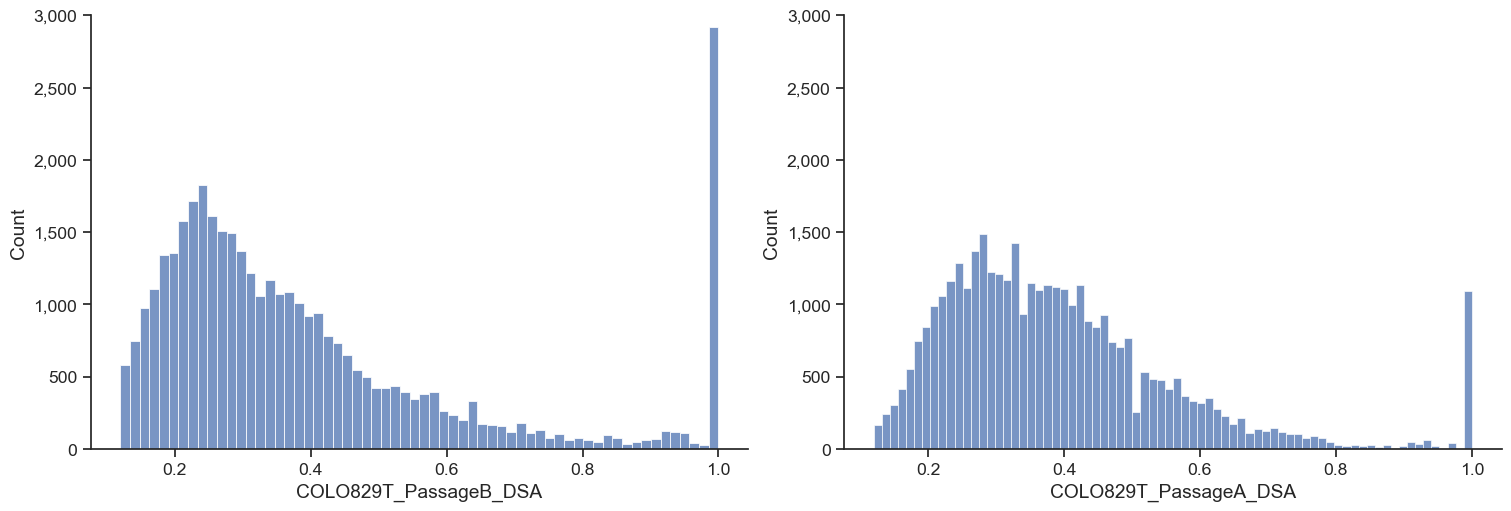

In [51]:
fig, axes = plt.subplots(1,2, figsize=(15,5), constrained_layout=True)
sns.histplot(colotb_snvs_pass_ad10_BiAcomp['COLO829T_PassageB_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[0])
axes[0].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[0].set_ylim(0, 3000)
sns.histplot(colota_snvs_pass_ad10_BiAcomp['COLO829T_PassageA_DSA'].str.split(':').apply(lambda x: float(x[vafindex])), ax=axes[1])
axes[1].get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[1].set_ylim(0, 3000)

In [50]:
axes

array([<Axes: xlabel='COLO829T_PassageB_DSA', ylabel='Count'>,
       <Axes: xlabel='COLO829T_PassageA_DSA', ylabel='Count'>],
      dtype=object)